In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

data = {
    "Country": ["India", "India", "USA", "USA", "UK", "UK"],
    "Date": ["2020-01-01", "2020-02-01", "2020-01-01", "2020-02-01", "2020-01-01", "2020-02-01"],
    "Confirmed": [100, 500, 200, 1000, 150, 700],
    "Recovered": [20, 100, 30, 200, 25, 150],
    "Deaths": [2, 10, 5, 20, 3, 15]
}

df = pd.DataFrame(data)
df.to_csv("covid.csv", index=False)

df.head()

,Country,Date,Confirmed,Recovered,Deaths
0,India,2020-01-01,100,20,2
1,India,2020-02-01,500,100,10
2,USA,2020-01-01,200,30,5
3,USA,2020-02-01,1000,200,20
4,UK,2020-01-01,150,25,3


In [4]:
df = pd.read_csv("covid.csv")
df.head()

,Country,Date,Confirmed,Recovered,Deaths
0,India,2020-01-01,100,20,2
1,India,2020-02-01,500,100,10
2,USA,2020-01-01,200,30,5
3,USA,2020-02-01,1000,200,20
4,UK,2020-01-01,150,25,3


In [5]:
df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Country    6 non-null      str           
 1   Date       6 non-null      datetime64[us]
 2   Confirmed  6 non-null      int64         
 3   Recovered  6 non-null      int64         
 4   Deaths     6 non-null      int64         
dtypes: datetime64[us](1), int64(3), str(1)
memory usage: 372.0 bytes


In [6]:
print("Total Confirmed:", df["Confirmed"].sum())
print("Total Recovered:", df["Recovered"].sum())
print("Total Deaths:", df["Deaths"].sum())

Total Confirmed: 2650
Total Recovered: 525
Total Deaths: 55


In [7]:
country = df.groupby("Country")[["Confirmed", "Recovered", "Deaths"]].max()
country.head()

,Confirmed,Recovered,Deaths
Country,,,
India,500,100,10
UK,700,150,15
USA,1000,200,20


In [8]:
highest = country["Confirmed"].idxmax()
print("Country with Highest Cases:", highest)

Country with Highest Cases: USA


In [9]:
average = np.mean(country["Confirmed"])
print("Average Confirmed Cases:", average)

Average Confirmed Cases: 733.3333333333334


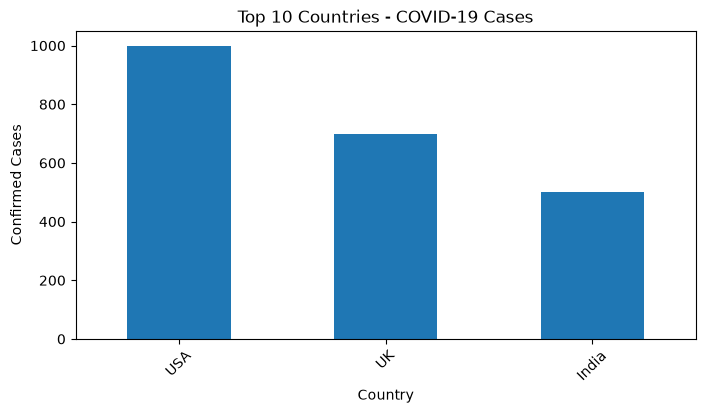

In [10]:
top10 = country.sort_values("Confirmed", ascending=False).head(10)

top10["Confirmed"].plot(kind="bar", figsize=(8,4))
plt.title("Top 10 Countries - COVID-19 Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()

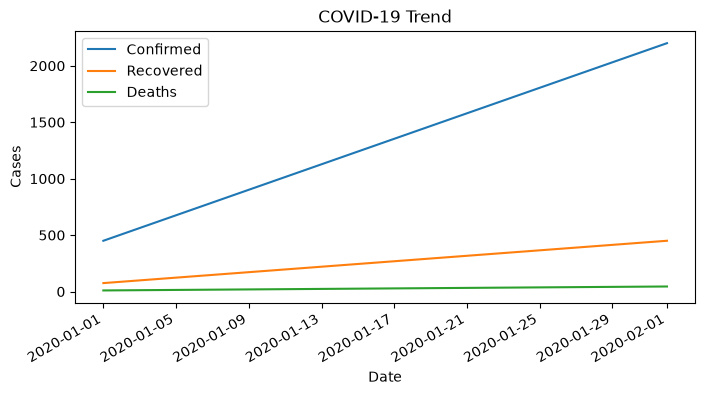

In [11]:
trend = df.groupby("Date")[["Confirmed", "Recovered", "Deaths"]].sum()

trend.plot(figsize=(8,4))
plt.title("COVID-19 Trend")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

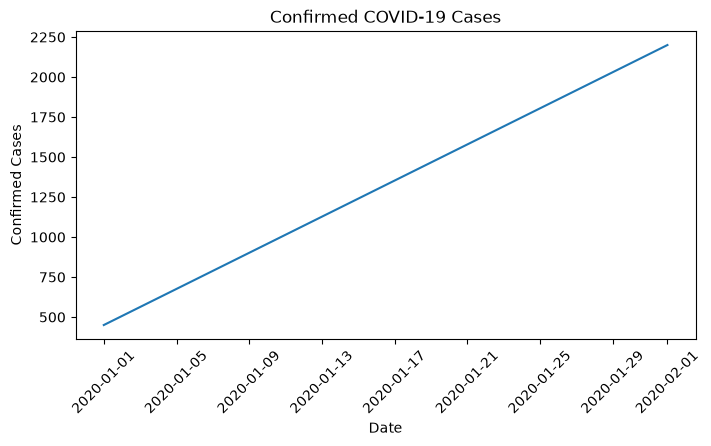

In [12]:
plt.figure(figsize=(8,4))

sns.lineplot(data=trend, x=trend.index, y="Confirmed")

plt.title("Confirmed COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()